# Detección de QRs — Pipeline Final

## Por qué el pipeline anterior daba 0%

| Causa | Diagnóstico |
|---|---|
| Búsqueda en esquinas de imagen | Los QRs están en el **margen blanco** alrededor de la goma, NO en las esquinas geométricas de la imagen |
| `cv2.QRCodeDetector` falla | Los QRs tienen **~2-3 px por módulo** — por debajo del mínimo del decoder |
| Filtro de finder patterns muy estricto | aspect ratio, área y jerarquía se relajan ahora |

## Estrategia correcta
1. **Segmentar bandas blancas** (zonas sin goma) por perfil de brillo de filas
2. **Buscar QRs en los extremos izq/der de cada banda** con ventana de búsqueda amplia
3. **Intentar decodificación** con upscale + CLAHE (a veces funciona)
4. **Fallback visual**: localizar el cuadrado más denso en bordes como posición del QR
5. **Asignar TL/TR/BR** por posición relativa dentro de banda top/bottom

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import os
import glob

IMAGE_PATH  = "../../data/michelin_dataset/Multimedia (31).jpg"
DATASET_PATH = "../../data/michelin_dataset"
N_QRS = 3

# Ajusta si las dimensiones físicas reales de la mesa son conocidas
REAL_COORDS_MM = {
    'TL': (0,   0),
    'TR': (600, 0),
    'BR': (600, 800),
    'BL': (0,   800),
}

## Módulo 1: Segmentación de bandas blancas

In [2]:
def find_white_bands(gray, brightness_threshold=155, min_band_height=30, gap_tolerance=20):
    """
    Detecta bandas horizontales donde el brillo medio de cada fila
    supera el umbral (= zonas blancas sin goma).

    Returns:
        List of (y_start, y_end) tuples.
    """
    row_means = gray.mean(axis=1)
    white_rows = np.where(row_means > brightness_threshold)[0]

    if len(white_rows) == 0:
        return []

    bands = []
    start = prev = int(white_rows[0])

    for r in white_rows[1:]:
        r = int(r)
        if r - prev > gap_tolerance:
            if prev - start >= min_band_height:
                bands.append((start, prev))
            start = r
        prev = r

    if prev - start >= min_band_height:
        bands.append((start, prev))

    return bands


print("Módulo 1 listo.")

Módulo 1 listo.


## Módulo 2: Localización de QR en una región

In [3]:
def locate_qr_in_region(img_bgr, gray_full, x1, y1, x2, y2,
                         decode_scales=(4, 6, 8, 10),
                         label=''):
    """
    Intenta detectar y localizar un QR dentro de la región [x1,x2] x [y1,y2].

    Estrategia dual:
      A) Decodificación: upscale + CLAHE → cv2.QRCodeDetector
      B) Localización visual: umbral adaptativo + contorno más cuadrado

    Returns:
        (cx, cy, size_px, decoded_data_or_None)
        o (None, None, None, None) si no se encuentra nada.
    """
    x1c = max(0, x1); y1c = max(0, y1)
    x2c = min(img_bgr.shape[1], x2)
    y2c = min(img_bgr.shape[0], y2)

    roi = img_bgr[y1c:y2c, x1c:x2c]
    roi_g = gray_full[y1c:y2c, x1c:x2c]

    if roi.size == 0:
        return None, None, None, None

    detector = cv2.QRCodeDetector()

    # ── A: intentar decodificación ────────────────────────────────────────
    for scale in decode_scales:
        big = cv2.resize(roi, None, fx=scale, fy=scale,
                         interpolation=cv2.INTER_LANCZOS4)
        big_g = cv2.cvtColor(big, cv2.COLOR_BGR2GRAY)
        clahe = cv2.createCLAHE(clipLimit=4.0, tileGridSize=(4, 4))
        enh = clahe.apply(big_g)

        for variant in [big, cv2.cvtColor(enh, cv2.COLOR_GRAY2BGR)]:
            ret, dec, pts, _ = detector.detectAndDecodeMulti(variant)
            if ret and pts is not None:
                p = (pts[0] / scale).astype(int)
                p[:, 0] += x1c
                p[:, 1] += y1c
                cx = int(p[:, 0].mean())
                cy = int(p[:, 1].mean())
                sz = int(np.linalg.norm(p[0] - p[1]))
                data = dec[0] if dec else ''
                return cx, cy, sz, data

    # ── B: localización visual (sin decodificación) ───────────────────────
    blur = cv2.GaussianBlur(roi_g, (3, 3), 0)
    clahe2 = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(4, 4))
    enh2 = clahe2.apply(blur)

    rH, rW = roi_g.shape
    best = None
    best_score = float('inf')

    for thresh_fn in [
        lambda g: cv2.adaptiveThreshold(g, 255,
            cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY_INV, 11, 2),
        lambda g: cv2.adaptiveThreshold(g, 255,
            cv2.ADAPTIVE_THRESH_MEAN_C, cv2.THRESH_BINARY_INV, 11, 3),
        lambda g: cv2.threshold(g, 0, 255,
            cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)[1],
    ]:
        binary = thresh_fn(enh2)
        cnts, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL,
                                    cv2.CHAIN_APPROX_SIMPLE)

        for cnt in cnts:
            area = cv2.contourArea(cnt)
            if area < 50 or area > rH * rW * 0.5:
                continue

            x, y, w, h = cv2.boundingRect(cnt)
            asp = w / (h + 1e-6)
            if not (0.4 < asp < 2.5):
                continue

            roi2 = roi_g[y:y+h, x:x+w]
            edges = cv2.Canny(roi2, 30, 100)
            edge_d = np.sum(edges > 0) / (edges.size + 1e-6)

            if edge_d < 0.04:   # sin estructura → no es QR
                continue

            # Score: más cuadrado y más rico en bordes = mejor
            score = abs(asp - 1.0) - edge_d * 2

            if score < best_score:
                best_score = score
                cx = x1c + x + w // 2
                cy = y1c + y + h // 2
                best = (cx, cy, max(w, h), None)

    return best if best else (None, None, None, None)


print("Módulo 2 listo.")

Módulo 2 listo.


## Módulo 3: Pipeline principal

In [4]:
def detect_qrs(image_path,
               brightness_threshold=155,
               search_margin_x=220,
               min_qr_size=15,
               show=True):
    """
    Pipeline completo de detección de QRs para el dataset Michelin.

    Parámetros ajustables:
        brightness_threshold : umbral de brillo para definir zona blanca (default 155)
        search_margin_x      : ancho (px) de la ventana de búsqueda en cada lado de banda (default 220)
        min_qr_size          : tamaño mínimo en px para aceptar un candidato (default 15)

    Returns:
        img_rgb : imagen RGB
        qrs     : dict con claves 'TL','TR','BR'(,'BL') y valores
                  {'center':(cx,cy), 'size':int, 'data':str_or_None}
    """
    img_bgr = cv2.imread(image_path)
    if img_bgr is None:
        raise FileNotFoundError(image_path)

    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    gray    = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    H, W    = gray.shape

    # 1. Bandas blancas
    bands = find_white_bands(gray, brightness_threshold=brightness_threshold)

    if not bands:
        print(f"  WARN: no se encontraron bandas blancas en {os.path.basename(image_path)}")
        return img_rgb, {}

    # 2. Buscar QR en extremos izq/der de cada banda
    raw_candidates = []   # (cx, cy, size, data, band_idx, side)

    for i, (r0, r1) in enumerate(bands):
        for side, (x1, x2) in [('L', (0, search_margin_x)),
                                 ('R', (W - search_margin_x, W))]:
            cx, cy, sz, data = locate_qr_in_region(
                img_bgr, gray, x1, r0, x2, r1,
                label=f'band{i}_{side}'
            )
            if cx is not None and (sz or 0) >= min_qr_size:
                raw_candidates.append((cx, cy, sz, data, i, side))

    # 3. Asignar etiquetas TL / TR / BR / BL
    qrs = {}

    top_band_y = bands[0][1]    # fila inferior de la banda superior
    bot_band_y  = bands[-1][0]  # fila superior de la banda inferior

    top_cands = [(cx, cy, sz, d) for cx,cy,sz,d,_,__ in raw_candidates if cy < H // 2]
    bot_cands = [(cx, cy, sz, d) for cx,cy,sz,d,_,__ in raw_candidates if cy >= H // 2]

    if top_cands:
        tl = min(top_cands, key=lambda c: c[0])   # más a la izquierda
        tr = max(top_cands, key=lambda c: c[0])   # más a la derecha
        qrs['TL'] = {'center': (tl[0], tl[1]), 'size': tl[2], 'data': tl[3]}
        if tr[0] != tl[0]:
            qrs['TR'] = {'center': (tr[0], tr[1]), 'size': tr[2], 'data': tr[3]}

    if bot_cands:
        # Usar el que esté más abajo y más a la derecha (depende de tu setup)
        # Si hay QR solo en un lado, sigue funcionando
        br = max(bot_cands, key=lambda c: c[0] + c[1])  # max x+y → bottom-right
        bl = min(bot_cands, key=lambda c: -c[0] + c[1]) # min x, max y → bottom-left

        qrs['BR'] = {'center': (br[0], br[1]), 'size': br[2], 'data': br[3]}
        if bl[0] != br[0]:
            qrs['BL'] = {'center': (bl[0], bl[1]), 'size': bl[2], 'data': bl[3]}

    if show:
        _visualize(img_rgb, qrs, bands, os.path.basename(image_path))

    return img_rgb, qrs


def _visualize(img_rgb, qrs, bands, title):
    H, W = img_rgb.shape[:2]
    colors = {'TL':(0,255,120), 'TR':(0,180,255), 'BR':(255,100,0), 'BL':(255,220,0)}

    fig, axes = plt.subplots(1, 2, figsize=(16, 8))

    overlay = img_rgb.copy()

    # Shading de bandas blancas
    band_overlay = np.zeros_like(overlay)
    for r0, r1 in bands:
        band_overlay[r0:r1, :] = (255, 255, 180)
    overlay = cv2.addWeighted(overlay, 0.85, band_overlay, 0.15, 0)

    for name, info in qrs.items():
        cx, cy = info['center']
        sz = (info['size'] or 35) + 15
        col = colors.get(name, (200, 200, 200))
        cv2.rectangle(overlay, (cx-sz, cy-sz), (cx+sz, cy+sz), col, 3)
        cv2.circle(overlay, (cx, cy), 7, col, -1)
        txt = name
        if info.get('data'):
            txt += f" '{info['data']}'"
        cv2.putText(overlay, txt, (cx-30, cy-sz-8),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.7, col, 2)

    # Zona de trabajo
    if len(qrs) >= 2:
        xs = [v['center'][0] for v in qrs.values()]
        ys = [v['center'][1] for v in qrs.values()]
        cv2.rectangle(overlay, (min(xs), min(ys)), (max(xs), max(ys)),
                      (255, 255, 0), 2)

    axes[0].imshow(overlay)
    decoded = sum(1 for v in qrs.values() if v.get('data'))
    axes[0].set_title(
        f'{title}\nQRs: {len(qrs)}/3  |  decodificados: {decoded}',
        fontsize=10, fontweight='bold'
    )
    axes[0].axis('off')

    # Zoom crops
    axes[1].axis('off')
    if qrs:
        n = len(qrs)
        PAD = 55
        inner_fig, inner_axes = plt.subplots(1, n, figsize=(n*3, 3))
        if n == 1:
            inner_axes = [inner_axes]
        for ax, (name, info) in zip(inner_axes, qrs.items()):
            cx, cy = info['center']
            x1 = max(0, cx-PAD); y1 = max(0, cy-PAD)
            x2 = min(W, cx+PAD); y2 = min(H, cy+PAD)
            roi = img_rgb[y1:y2, x1:x2]
            scale = 5
            big = cv2.resize(roi, None, fx=scale, fy=scale,
                             interpolation=cv2.INTER_LANCZOS4)
            ax.imshow(big)
            col = colors.get(name, (200,200,200))
            ax.set_title(f'{name} x{scale}', fontsize=8,
                         color=tuple(c/255 for c in col))
            ax.axis('off')
        plt.tight_layout()
        plt.show()

    plt.tight_layout()
    plt.show()


print("Módulo 3 listo.")

Módulo 3 listo.


## Test sobre una imagen

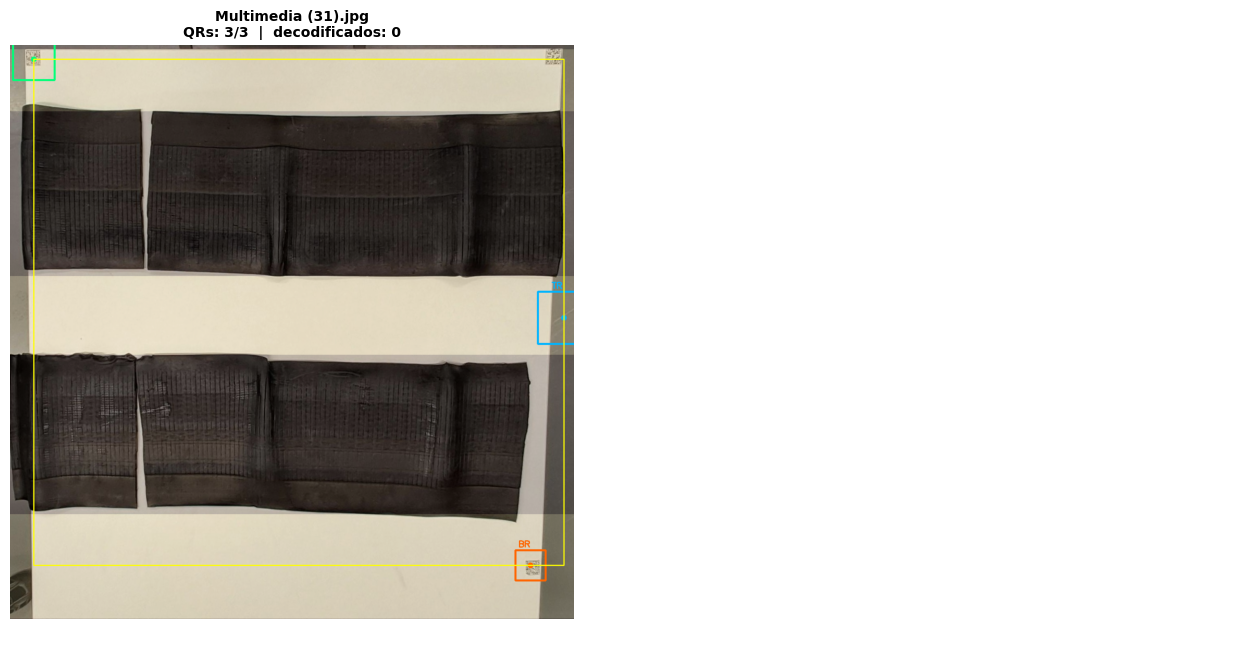

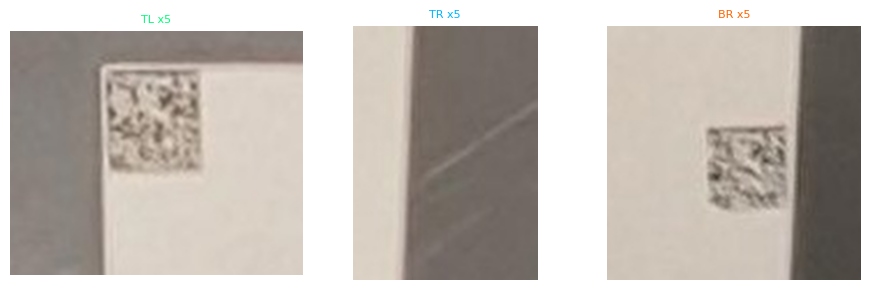

<Figure size 640x480 with 0 Axes>


Resultado:
  BR: center=(1276, 1278)  size=22px  data='None'
  TL: center=(58, 37)  size=36px  data='None'
  TR: center=(1358, 671)  size=49px  data='None'


In [5]:
img_rgb, qrs = detect_qrs(IMAGE_PATH, show=True)

print("\nResultado:")
for k, v in sorted(qrs.items()):
    print(f"  {k}: center={v['center']}  size={v['size']}px  data='{v['data']}'")

## Módulo 4: Homografía y medición en mm

In [6]:
def compute_homography(qrs, real_coords_mm):
    """
    Calcula H: imagen (px) → coordenadas reales (mm).
    Necesita al menos 4 puntos comunes para homografía exacta,
    o 3 para transformación afín.
    """
    common = [k for k in real_coords_mm if k in qrs]
    if len(common) < 3:
        raise ValueError(f"Solo {len(common)} puntos comunes, mínimo 3.")

    img_pts  = np.array([qrs[k]['center'] for k in common], dtype=np.float32)
    real_pts = np.array([real_coords_mm[k] for k in common], dtype=np.float32)

    if len(common) >= 4:
        H, _ = cv2.findHomography(img_pts, real_pts, cv2.RANSAC, 5.0)
    else:
        A = cv2.getAffineTransform(img_pts[:3], real_pts[:3])
        H = np.vstack([A, [0, 0, 1]])

    return H, np.linalg.inv(H), common


def px_to_mm(pt_px, H):
    pt = np.array([pt_px[0], pt_px[1], 1.0])
    r  = H @ pt
    return float(r[0]/r[2]), float(r[1]/r[2])


def measure_gap_mm(pt1_px, pt2_px, H):
    p1 = px_to_mm(pt1_px, H)
    p2 = px_to_mm(pt2_px, H)
    d  = np.sqrt((p2[0]-p1[0])**2 + (p2[1]-p1[1])**2)
    return d, p1, p2


# ── Uso ──────────────────────────────────────────────────────────────────
if len(qrs) >= 3:
    H, H_inv, used_pts = compute_homography(qrs, REAL_COORDS_MM)
    print(f"Homografía calculada con puntos: {used_pts}")
    print(f"H =\n{H}")

    # Ejemplo: medir separación entre dos bordes de la goma
    # Sustituye con las coordenadas reales detectadas en tu pipeline de goma
    # borde_izq = (440, 300)  # px — borde derecho de tira izquierda
    # borde_der = (460, 300)  # px — borde izquierdo de tira derecha
    # gap_mm, p1, p2 = measure_gap_mm(borde_izq, borde_der, H)
    # print(f"Separación: {gap_mm:.2f} mm")
else:
    print(f"Solo {len(qrs)} QRs detectados, se necesitan al menos 3 para homografía.")

Homografía calculada con puntos: ['TL', 'TR', 'BR']
H =
[[  0.43301058   0.05849566 -27.27895298]
 [ -0.60302846   1.23649368 -10.77461574]
 [  0.           0.           1.        ]]


## Evaluación sobre todo el dataset

Imágenes: 22
  [OK  ] Multimedia (31).jpg: 3 QRs (0 decoded) ['TL', 'TR', 'BR']


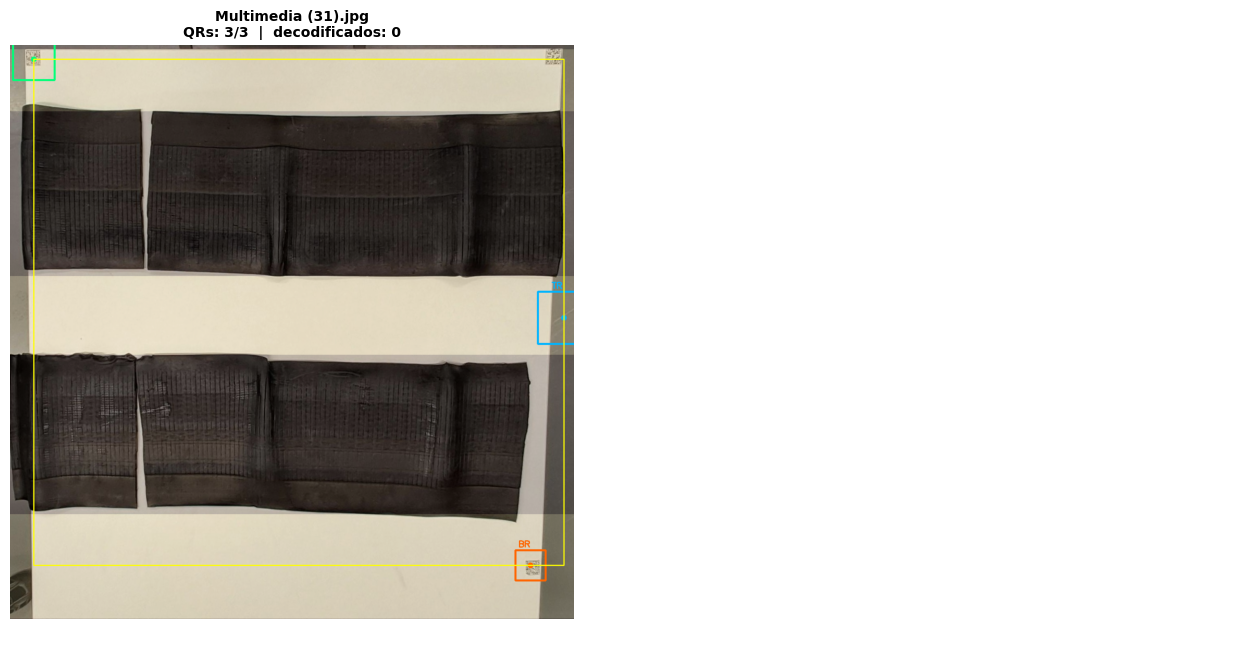

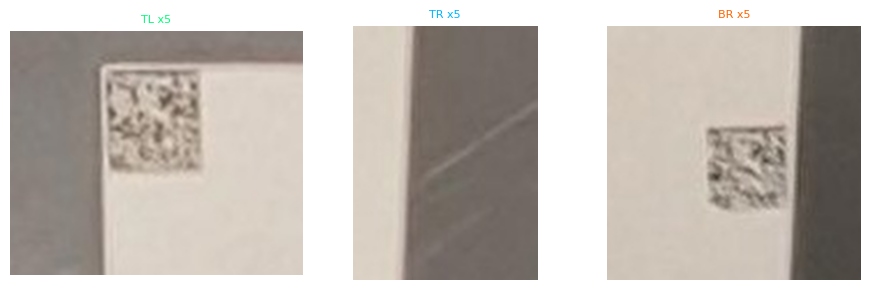

<Figure size 640x480 with 0 Axes>

  [OK  ] Multimedia (32).jpg: 3 QRs (0 decoded) ['TL', 'TR', 'BR']


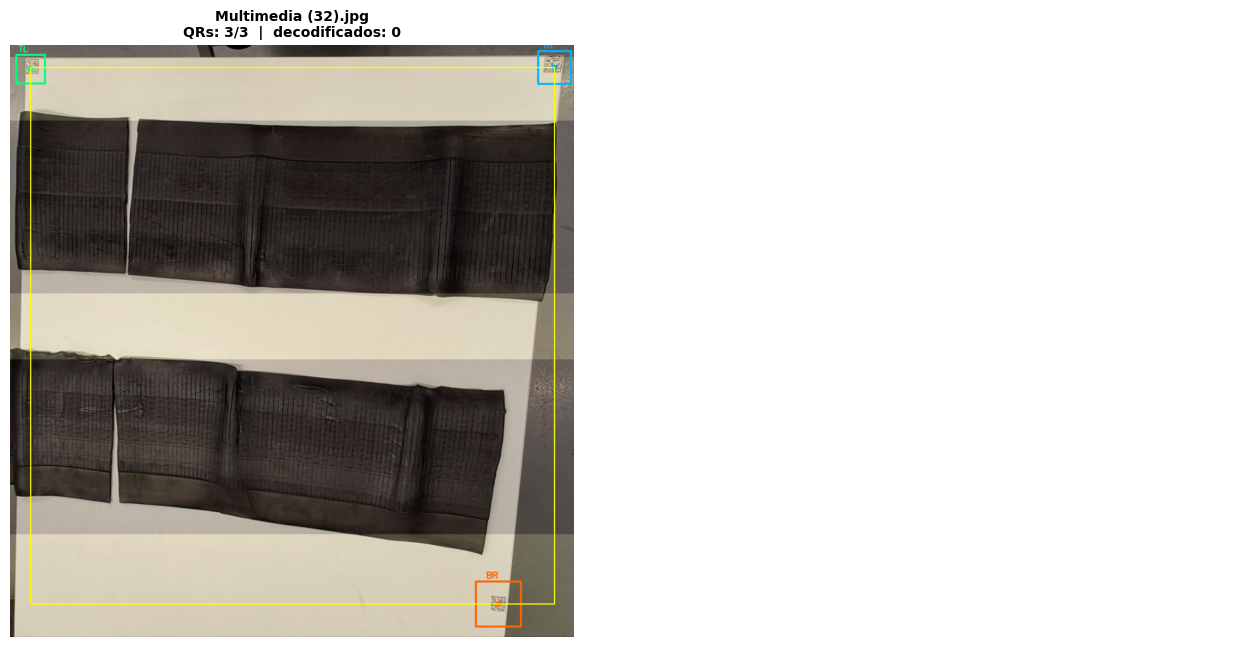

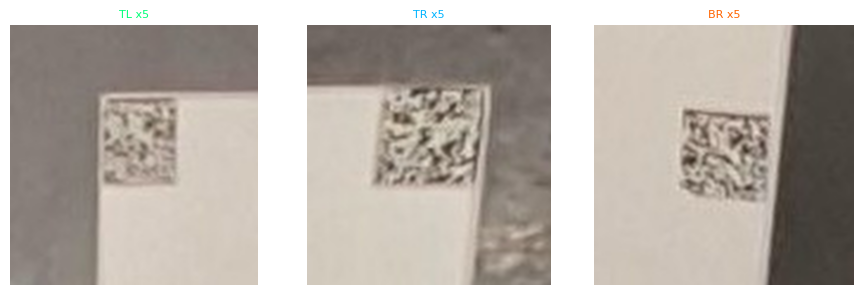

<Figure size 640x480 with 0 Axes>

  [OK  ] Multimedia (33).jpg: 4 QRs (0 decoded) ['TL', 'TR', 'BR', 'BL']


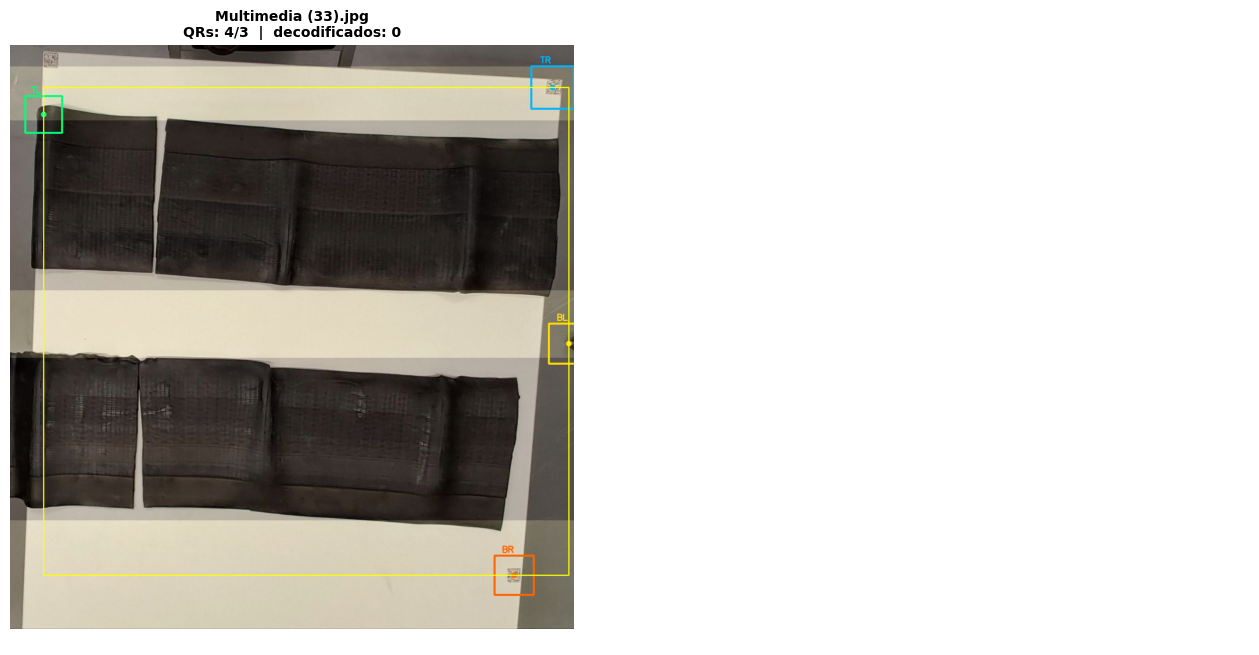

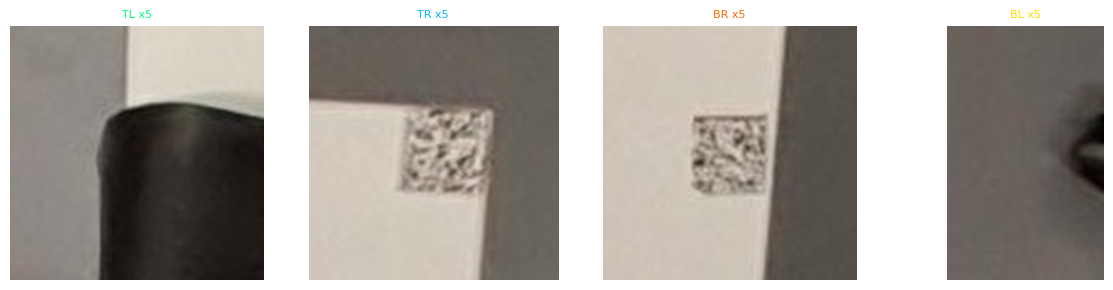

<Figure size 640x480 with 0 Axes>

  [OK  ] Multimedia (34).jpg: 3 QRs (0 decoded) ['TL', 'TR', 'BR']


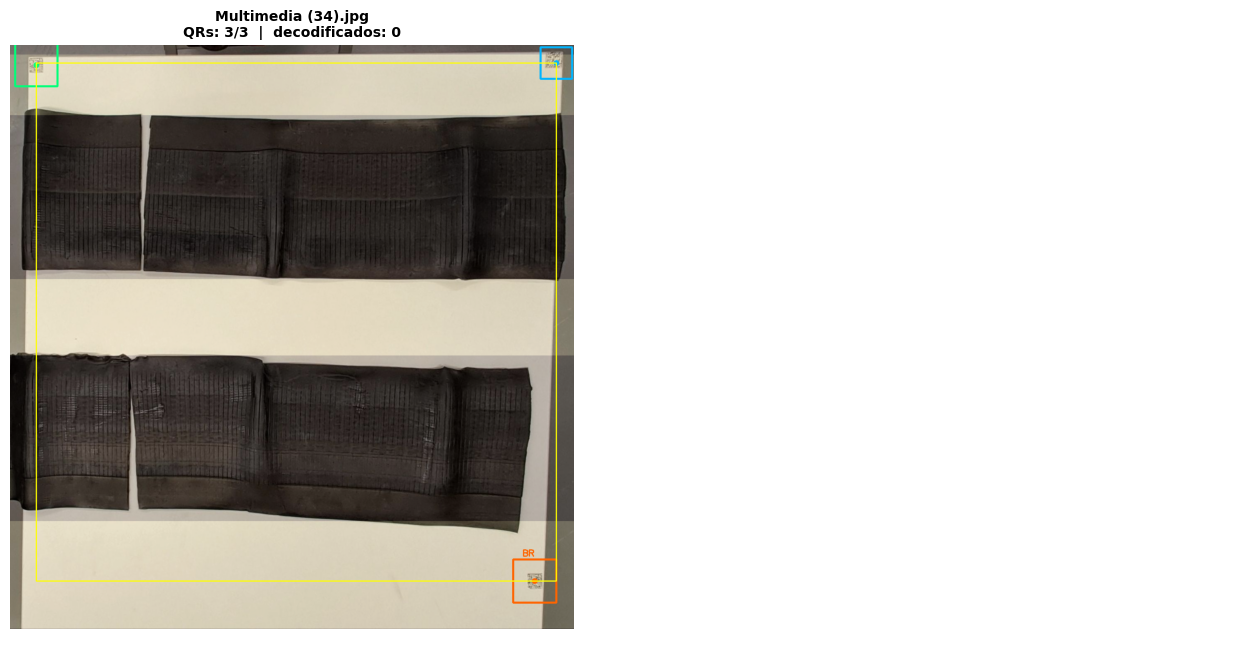

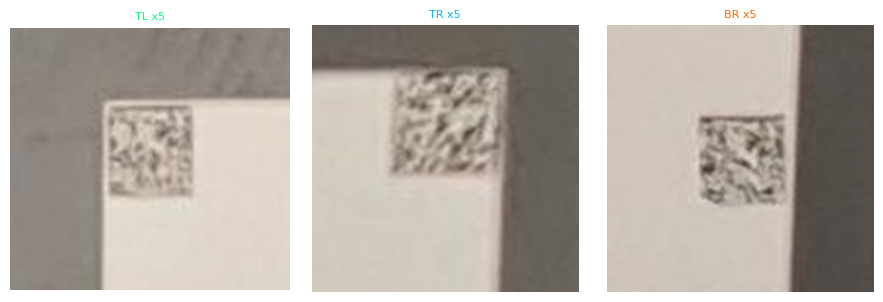

<Figure size 640x480 with 0 Axes>

  WARN: no se encontraron bandas blancas en Multimedia (35).jpg
  [FAIL] Multimedia (35).jpg: 0 QRs (0 decoded) []
  WARN: no se encontraron bandas blancas en Multimedia (35).jpg
  WARN: no se encontraron bandas blancas en Multimedia (36).jpg
  [FAIL] Multimedia (36).jpg: 0 QRs (0 decoded) []
  WARN: no se encontraron bandas blancas en Multimedia (36).jpg
  WARN: no se encontraron bandas blancas en Multimedia (37).jpg
  [FAIL] Multimedia (37).jpg: 0 QRs (0 decoded) []
  WARN: no se encontraron bandas blancas en Multimedia (37).jpg
  WARN: no se encontraron bandas blancas en Multimedia (38).jpg
  [FAIL] Multimedia (38).jpg: 0 QRs (0 decoded) []
  WARN: no se encontraron bandas blancas en Multimedia (38).jpg
  [OK  ] Multimedia (39).jpg: 3 QRs (0 decoded) ['TL', 'TR', 'BR']


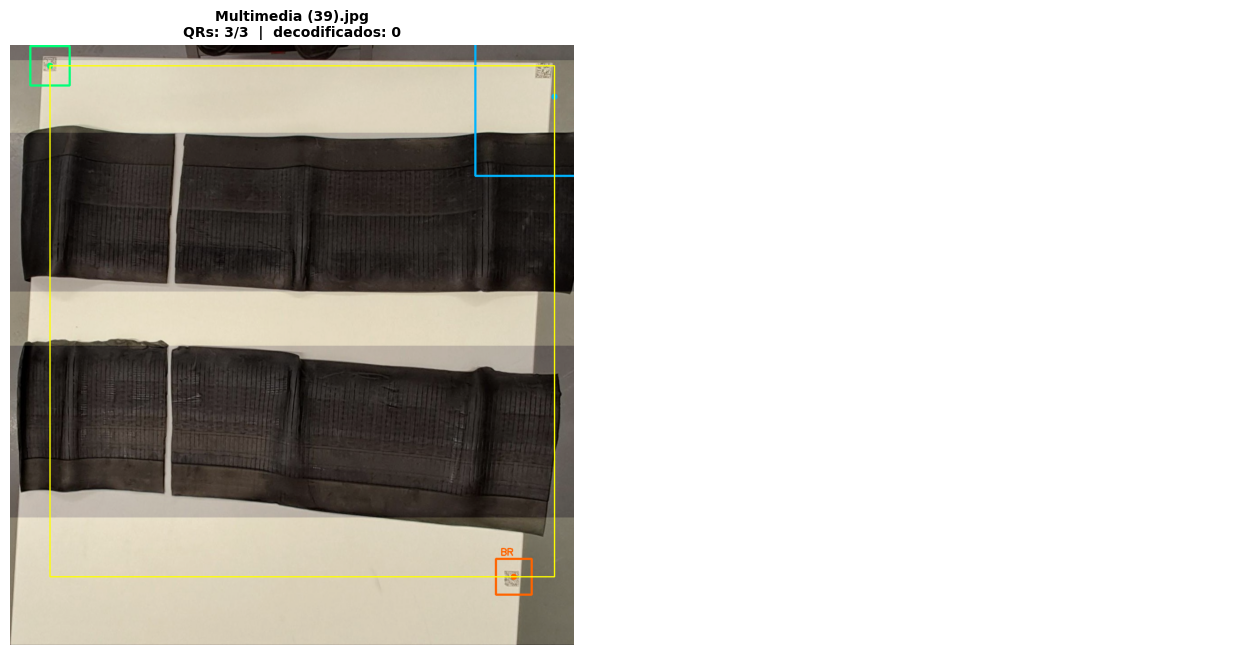

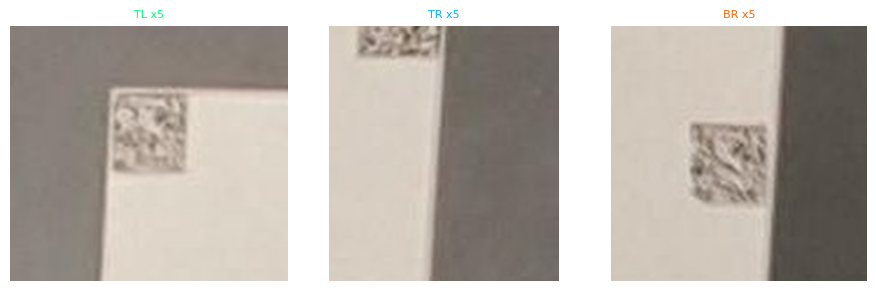

<Figure size 640x480 with 0 Axes>

  [FAIL] Multimedia (40).jpg: 2 QRs (0 decoded) ['TL', 'TR']


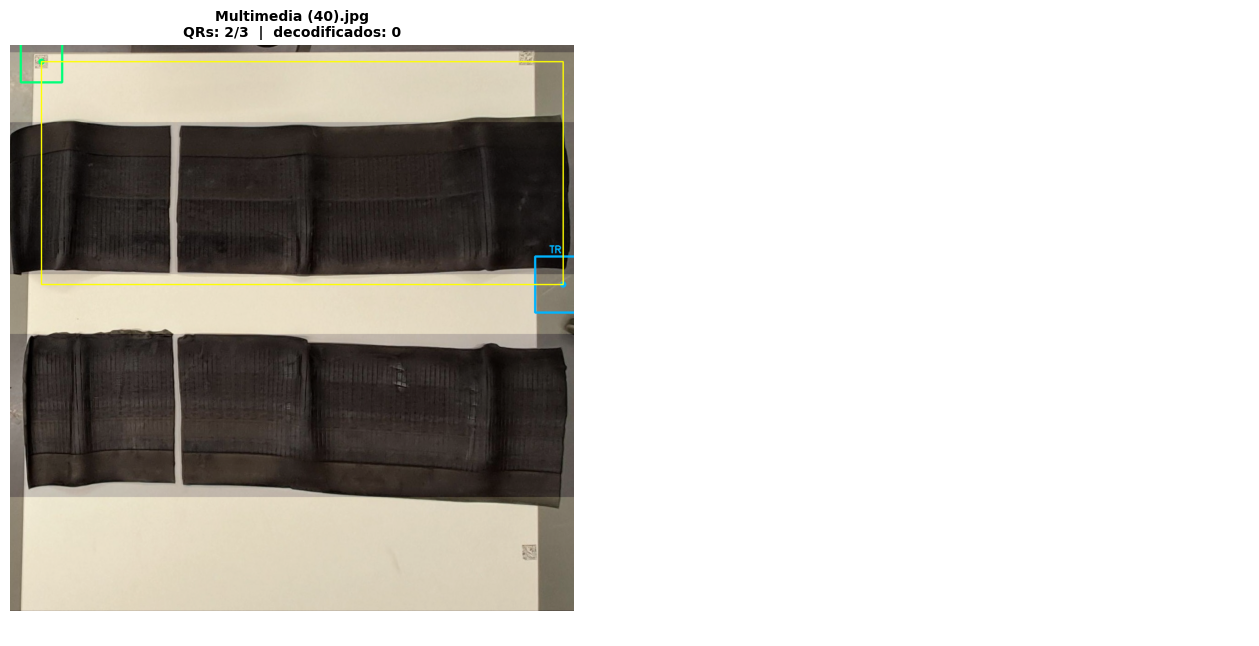

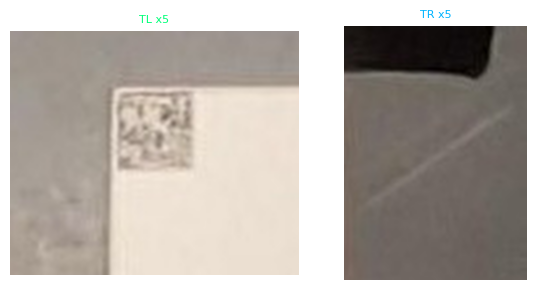

<Figure size 640x480 with 0 Axes>

  [OK  ] Multimedia (41).jpg: 4 QRs (0 decoded) ['TL', 'TR', 'BR', 'BL']


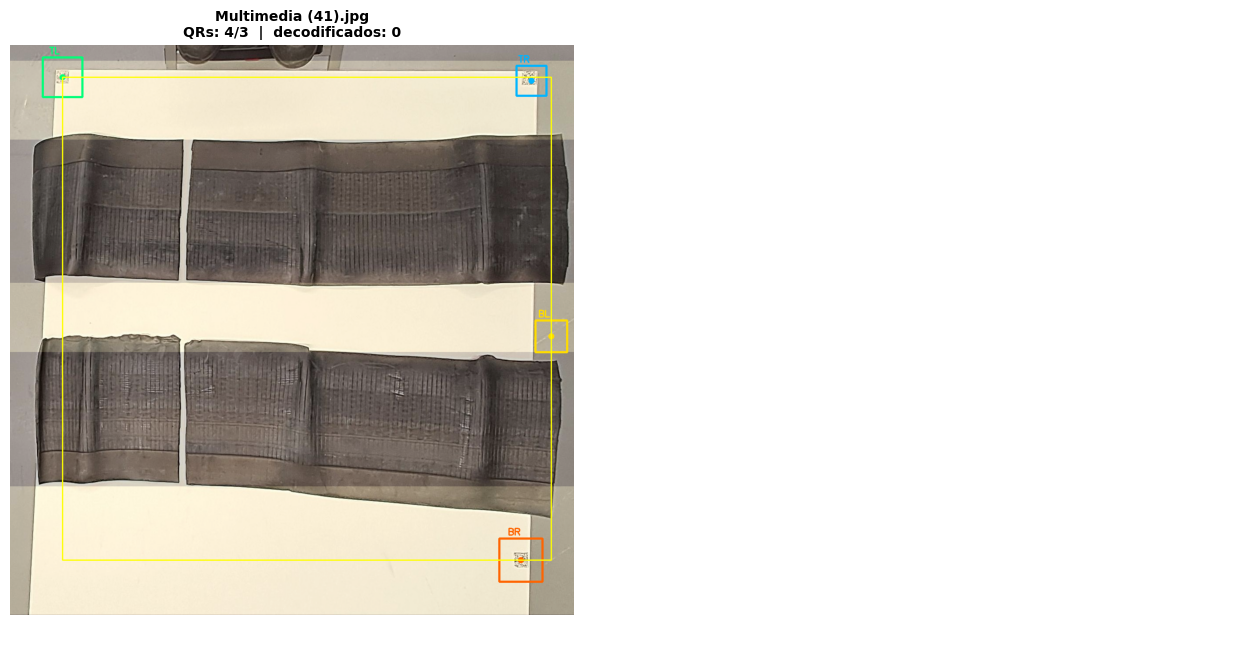

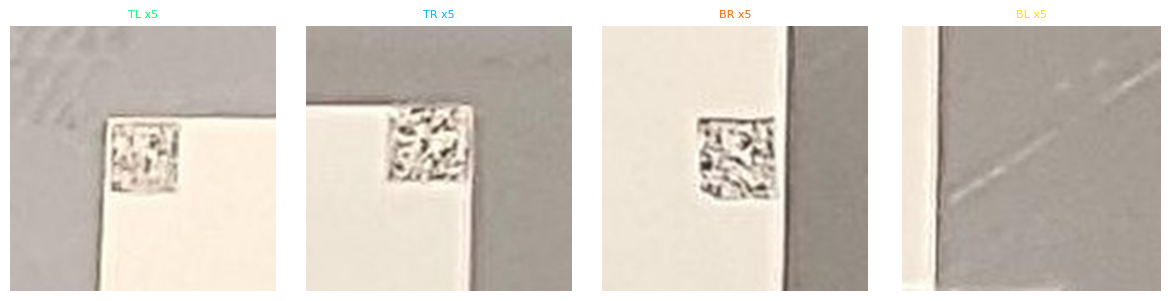

<Figure size 640x480 with 0 Axes>

  [OK  ] Multimedia (42).jpg: 4 QRs (0 decoded) ['TL', 'TR', 'BR', 'BL']


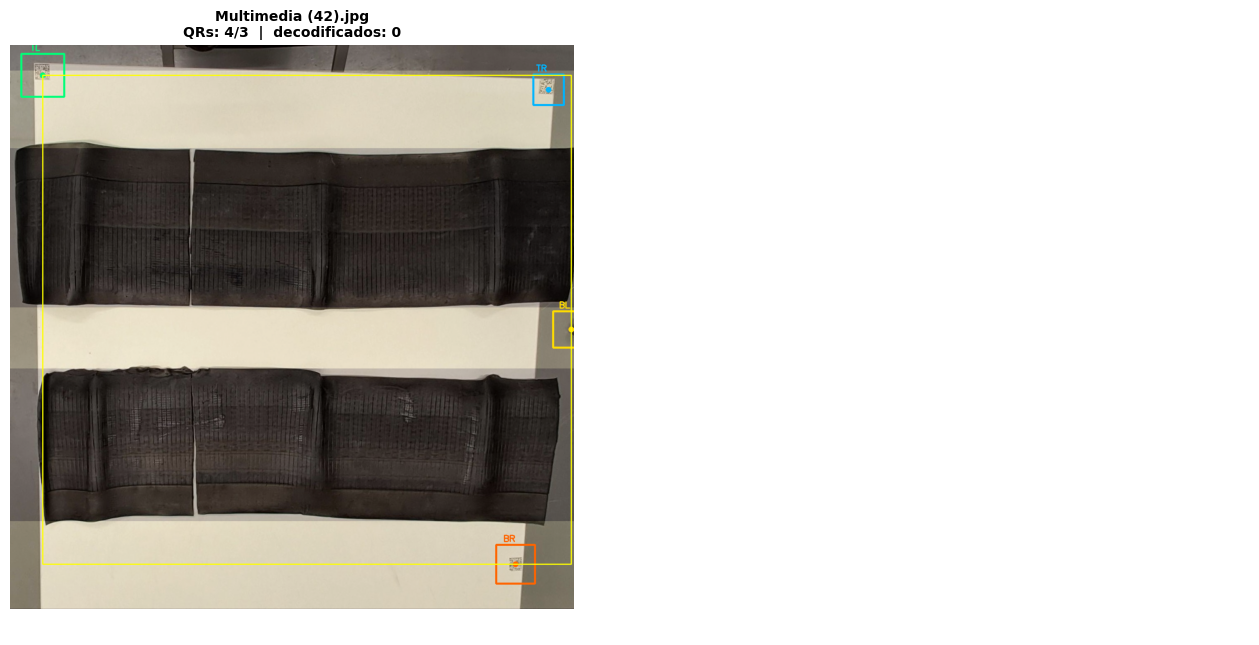

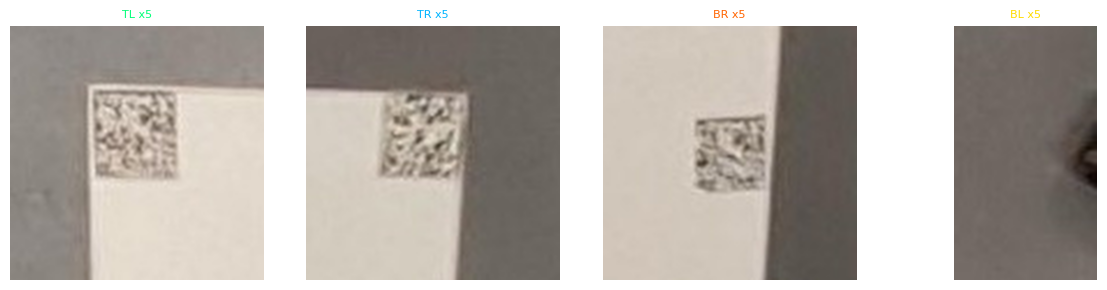

<Figure size 640x480 with 0 Axes>

  [OK  ] Multimedia (43).jpg: 3 QRs (0 decoded) ['TL', 'TR', 'BR']


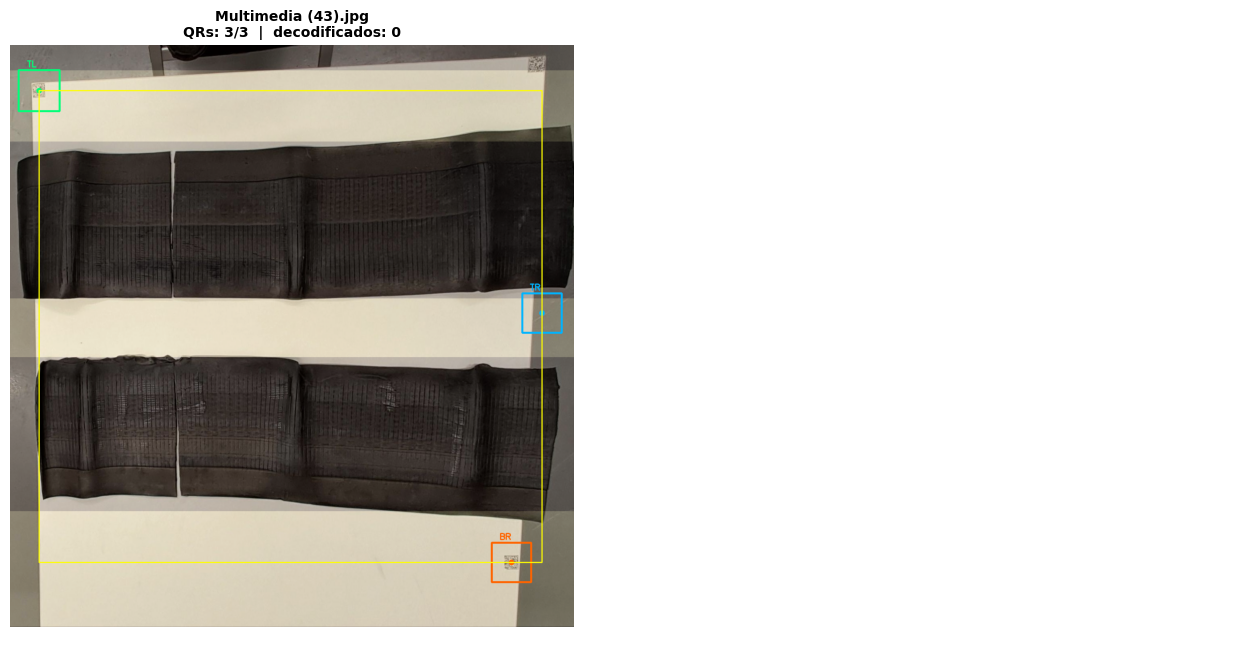

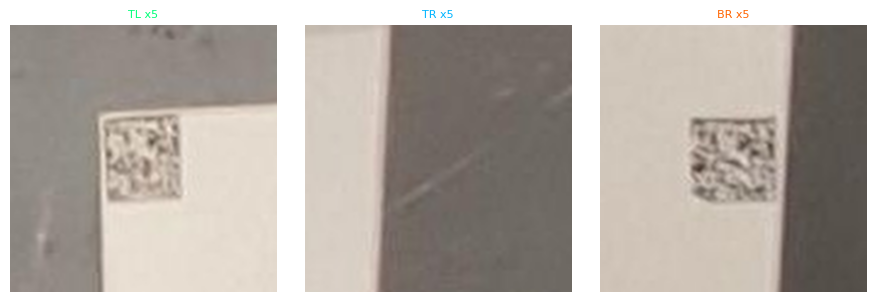

<Figure size 640x480 with 0 Axes>

  WARN: no se encontraron bandas blancas en Multimedia (44).jpg
  [FAIL] Multimedia (44).jpg: 0 QRs (0 decoded) []
  WARN: no se encontraron bandas blancas en Multimedia (44).jpg
  WARN: no se encontraron bandas blancas en Multimedia (45).jpg
  [FAIL] Multimedia (45).jpg: 0 QRs (0 decoded) []
  WARN: no se encontraron bandas blancas en Multimedia (45).jpg
  WARN: no se encontraron bandas blancas en Multimedia (46).jpg
  [FAIL] Multimedia (46).jpg: 0 QRs (0 decoded) []
  WARN: no se encontraron bandas blancas en Multimedia (46).jpg
  WARN: no se encontraron bandas blancas en Multimedia (47).jpg
  [FAIL] Multimedia (47).jpg: 0 QRs (0 decoded) []
  WARN: no se encontraron bandas blancas en Multimedia (47).jpg
  WARN: no se encontraron bandas blancas en Multimedia (48).jpg
  [FAIL] Multimedia (48).jpg: 0 QRs (0 decoded) []
  WARN: no se encontraron bandas blancas en Multimedia (48).jpg
  WARN: no se encontraron bandas blancas en Multimedia (49).jpg
  [FAIL] Multimedia (49).jpg: 0 QRs (0 de

In [7]:
image_paths = sorted(glob.glob(os.path.join(DATASET_PATH, "*.jpg")))
print(f"Imágenes: {len(image_paths)}")

summary = []
for path in image_paths:
    fname = os.path.basename(path)
    try:
        _, qrs_i = detect_qrs(path, show=False)
        n = len(qrs_i)
        decoded = sum(1 for v in qrs_i.values() if v.get('data'))
        ok = n >= N_QRS
        summary.append((fname, n, decoded, ok))
        tag = 'OK  ' if ok else 'FAIL'
        print(f"  [{tag}] {fname}: {n} QRs ({decoded} decoded) {[k for k in qrs_i]}")
    except Exception as e:
        summary.append((fname, 0, 0, False))
        print(f"  [ERR ] {fname}: {e}")

    # Opcional: mostrar cada imagen con detecciones
    detect_qrs(path, show=True)


n_ok = sum(1 for *_, ok in summary if ok)
print(f"\nDetección exitosa: {n_ok}/{len(image_paths)} ({100*n_ok/max(len(image_paths),1):.1f}%)")

# Parámetros a ajustar si el resultado no es bueno:
# - brightness_threshold: bajar si la mesa es más oscura
# - search_margin_x: subir si los QRs están más al centro
# - min_qr_size: bajar si la resolución es menor